<a href="https://colab.research.google.com/github/emortalizer/Colab-Assignment-15-BMW/blob/main/Assignment_fifteen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Upload the CSV file to Google Colab
from google.colab import files
uploaded = files.upload()

Saving bank-loan.csv to bank-loan.csv


In [18]:
# --- import libraries -----

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('bank-loan.csv')
print(df.shape)  # (850, 9)
df_labeled = df.dropna(subset=['default']).copy()  # 700 rows
print(df_labeled.isnull().sum())  # No missing values in features
print(df_labeled['default'].value_counts(normalize=True))  # ~73.9% non-default, 26.1% default

# Summary statistics
print(df_labeled.describe())

# ed (education level) distribution
print(df_labeled['ed'].value_counts().sort_index())

(850, 9)
age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64
default
0.0    0.738571
1.0    0.261429
Name: proportion, dtype: float64
              age          ed      employ     address      income     debtinc  \
count  700.000000  700.000000  700.000000  700.000000  700.000000  700.000000   
mean    34.860000    1.722857    8.388571    8.278571   45.601429   10.260571   
std      7.997342    0.928206    6.658039    6.824877   36.814226    6.827234   
min     20.000000    1.000000    0.000000    0.000000   14.000000    0.400000   
25%     29.000000    1.000000    3.000000    3.000000   24.000000    5.000000   
50%     34.000000    1.000000    7.000000    7.000000   34.000000    8.600000   
75%     40.000000    2.000000   12.000000   12.000000   55.000000   14.125000   
max     56.000000    5.000000   31.000000   34.000000  446.000000   41.300000   

         creddebt     othdebt     default  
count

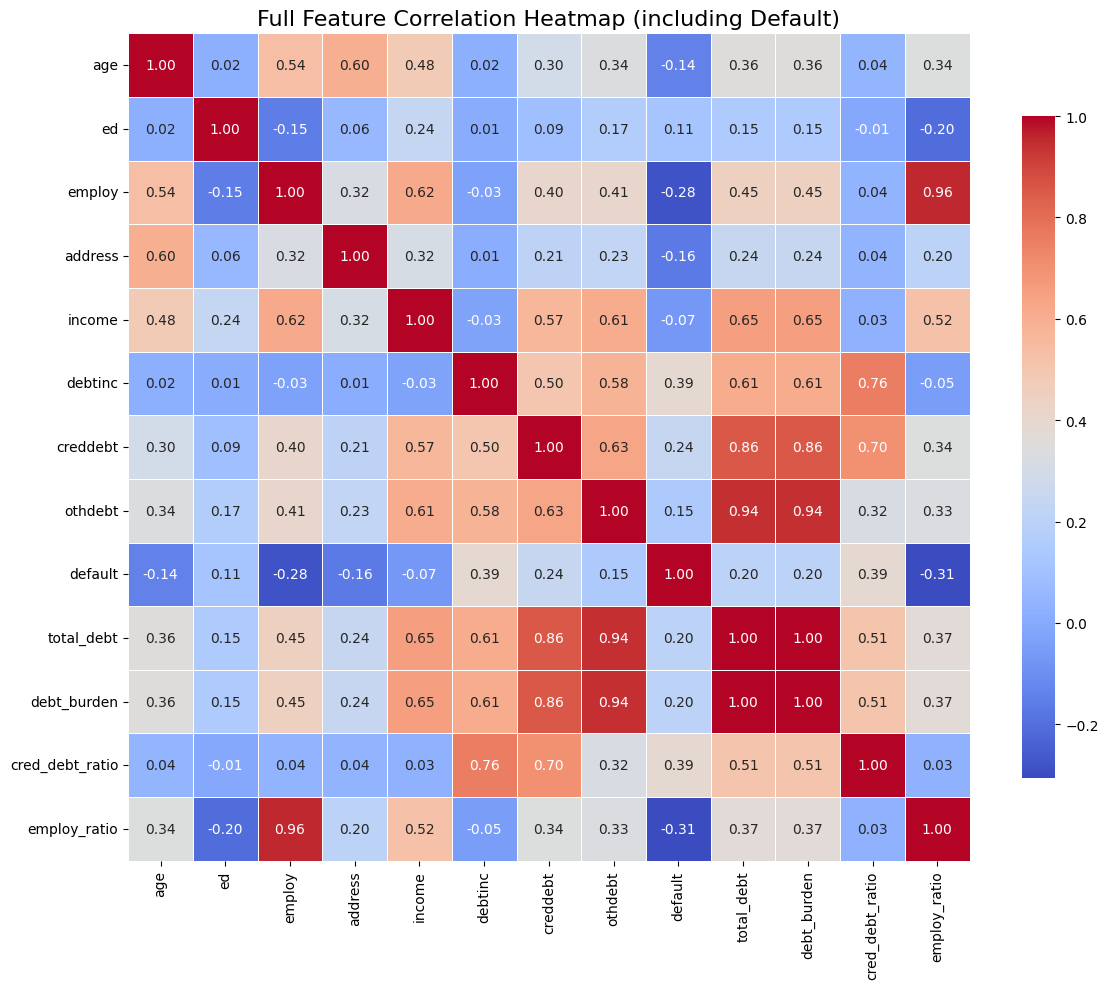

=== Correlations with Default (strongest first) ===
default            1.000
debtinc            0.390
cred_debt_ratio    0.389
employ_ratio      -0.306
employ            -0.283
creddebt           0.245
debt_burden        0.203
total_debt         0.203
address           -0.164
othdebt            0.146
age               -0.138
ed                 0.115
income            -0.071
Name: default, dtype: float64


In [16]:
# Full correlation matrix including default
corr = df_labeled.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Full Feature Correlation Heatmap (including Default)', fontsize=16)
plt.tight_layout()
plt.show()

# Bonus: Correlations sorted by strength with 'default'
print("=== Correlations with Default (strongest first) ===")
print(corr['default'].sort_values(key=abs, ascending=False).round(3))

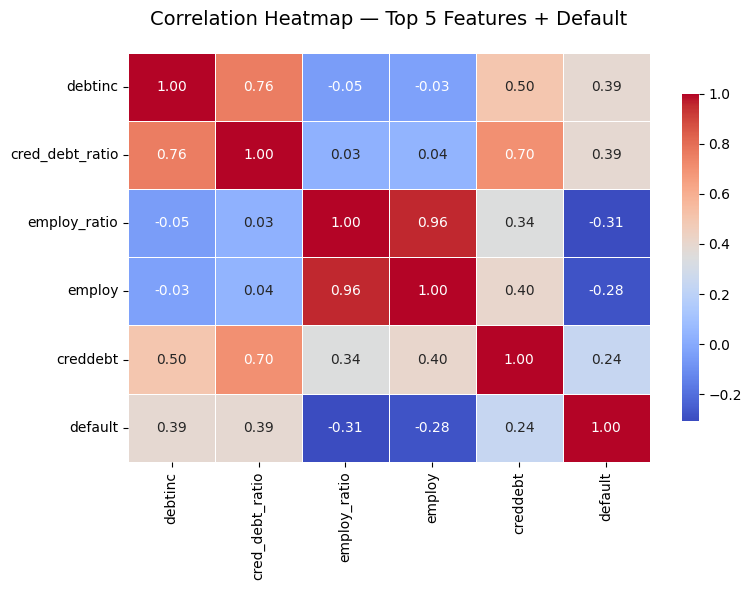

In [20]:
df = pd.read_csv('bank-loan.csv')
df_labeled = df.dropna(subset=['default']).copy()

# Feature engineering (same as before)
df_labeled['total_debt'] = df_labeled['creddebt'] + df_labeled['othdebt']
df_labeled['debt_burden'] = df_labeled['debtinc'] * df_labeled['income'] / 100
df_labeled['cred_debt_ratio'] = df_labeled['creddebt'] / (df_labeled['income'] + 1)
df_labeled['employ_ratio'] = df_labeled['employ'] / (df_labeled['age'] + 1)

# Top 5 features by absolute correlation with default
top5_features = ['debtinc', 'cred_debt_ratio', 'employ_ratio', 'employ', 'creddebt']
cols = top5_features + ['default']

# Simple heatmap
plt.figure(figsize=(8, 6))
corr_top5 = df_labeled[cols].corr()
sns.heatmap(corr_top5, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Top 5 Features + Default', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_14707/2174642547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='debtinc', data=df_labeled, palette=['#1f77b4', '#ff7f0e'])


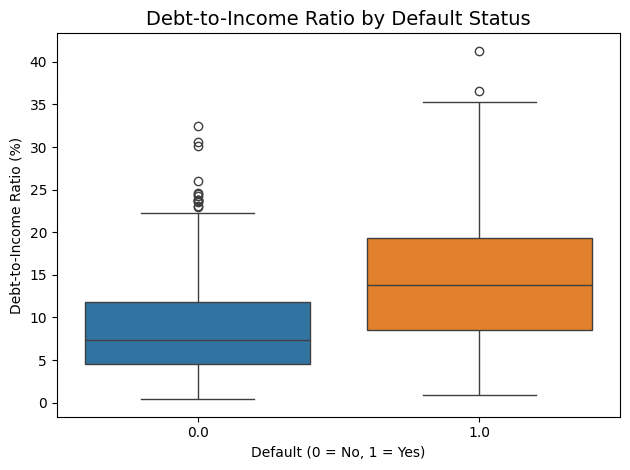

In [21]:
# 2. Debt-to-Income Ratio by Default Status (Boxplot)
plt.figure()
sns.boxplot(x='default', y='debtinc', data=df_labeled, palette=['#1f77b4', '#ff7f0e'])
plt.title('Debt-to-Income Ratio by Default Status', fontsize=14)
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Debt-to-Income Ratio (%)')
plt.tight_layout()
plt.savefig('debtinc_by_default.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_14707/2614302635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='employ', data=df_labeled, palette=['#1f77b4', '#ff7f0e'])


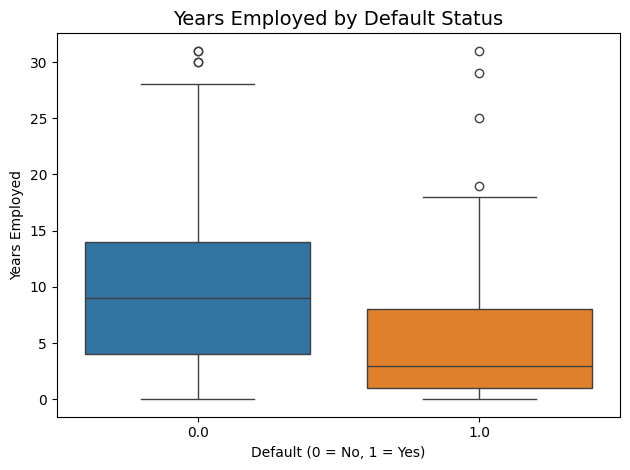

In [8]:
# 3. Years Employed by Default Status (Boxplot)
plt.figure()
sns.boxplot(x='default', y='employ', data=df_labeled, palette=['#1f77b4', '#ff7f0e'])
plt.title('Years Employed by Default Status', fontsize=14)
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Years Employed')
plt.tight_layout()
plt.savefig('employ_by_default.png', dpi=300, bbox_inches='tight')
plt.show()

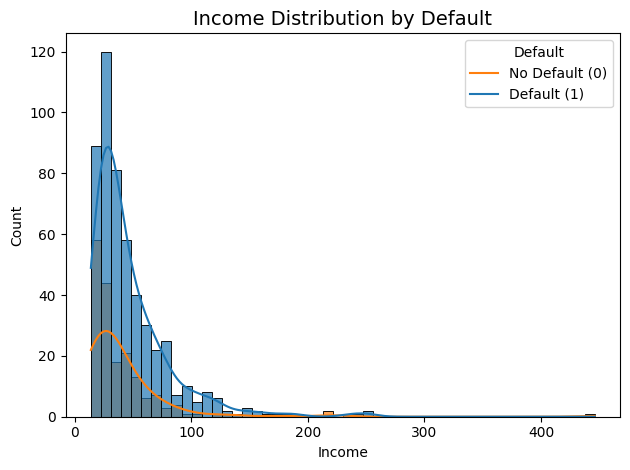

In [9]:
# 4. Income Distribution by Default (Histogram + KDE)
plt.figure()
sns.histplot(data=df_labeled, x='income', hue='default', kde=True,
             bins=50, alpha=0.7, palette=['#1f77b4', '#ff7f0e'])
plt.title('Income Distribution by Default', fontsize=14)
plt.xlabel('Income')
plt.ylabel('Count')
plt.legend(title='Default', labels=['No Default (0)', 'Default (1)'])
plt.tight_layout()
plt.savefig('income_dist.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_14707/2694803931.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='default', data=df_labeled, palette=['#1f77b4', '#ff7f0e'])


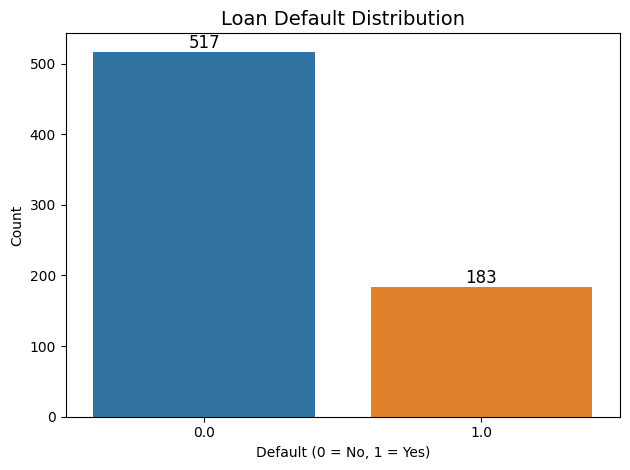

=== Summary Statistics ===
          age      ed  employ  address  income  debtinc  creddebt  othdebt  \
count  700.00  700.00  700.00   700.00  700.00   700.00    700.00   700.00   
mean    34.86    1.72    8.39     8.28   45.60    10.26      1.55     3.06   
std      8.00    0.93    6.66     6.82   36.81     6.83      2.12     3.29   
min     20.00    1.00    0.00     0.00   14.00     0.40      0.01     0.05   
25%     29.00    1.00    3.00     3.00   24.00     5.00      0.37     1.04   
50%     34.00    1.00    7.00     7.00   34.00     8.60      0.85     1.99   
75%     40.00    2.00   12.00    12.00   55.00    14.12      1.90     3.92   
max     56.00    5.00   31.00    34.00  446.00    41.30     20.56    27.03   

       default  
count   700.00  
mean      0.26  
std       0.44  
min       0.00  
25%       0.00  
50%       0.00  
75%       1.00  
max       1.00  

Default Rate: 26.1 %


In [10]:
# 5. Loan Default Distribution (Countplot)
plt.figure()
ax = sns.countplot(x='default', data=df_labeled, palette=['#1f77b4', '#ff7f0e'])
plt.title('Loan Default Distribution', fontsize=14)
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('default_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Bonus: Summary Statistics (printed)
print("=== Summary Statistics ===")
print(df_labeled.describe().round(2))
print("\nDefault Rate:", df_labeled['default'].mean().round(3) * 100, "%")

In [11]:
# Feature engineering
df_labeled['total_debt'] = df_labeled['creddebt'] + df_labeled['othdebt']
df_labeled['debt_burden'] = df_labeled['debtinc'] * df_labeled['income'] / 100  # absolute debt estimate
df_labeled['cred_debt_ratio'] = df_labeled['creddebt'] / (df_labeled['income'] + 1)  # avoid div-by-zero
df_labeled['employ_ratio'] = df_labeled['employ'] / (df_labeled['age'] + 1)

# Features list (original + new)
features = ['age', 'ed', 'employ', 'address', 'income', 'debtinc',
            'creddebt', 'othdebt', 'total_debt', 'debt_burden',
            'cred_debt_ratio', 'employ_ratio']
X = df_labeled[features]
y = df_labeled['default']

# Scaling (optional for RF, required for some models)
from sklearn.preprocessing import StandardScaler  # (in full env)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

=== Model Performance (Top 5 Features) ===
Accuracy: 0.8

Confusion Matrix:
 [[86 17]
 [11 26]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.83      0.86       103
         1.0       0.60      0.70      0.65        37

    accuracy                           0.80       140
   macro avg       0.75      0.77      0.76       140
weighted avg       0.81      0.80      0.80       140



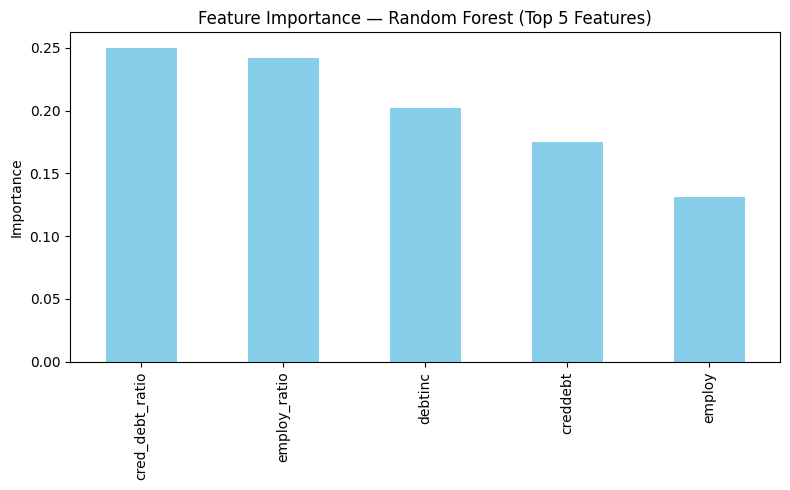

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Use only the top 5 strongest features
features = ['debtinc', 'cred_debt_ratio', 'employ_ratio', 'employ', 'creddebt']
X = df_labeled[features]
y = df_labeled['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200,
                            max_depth=8,
                            class_weight='balanced',
                            random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("=== Model Performance (Top 5 Features) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='skyblue')
plt.title('Feature Importance — Random Forest (Top 5 Features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

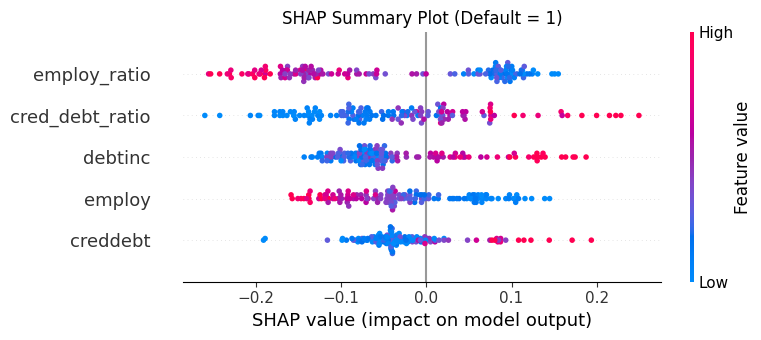

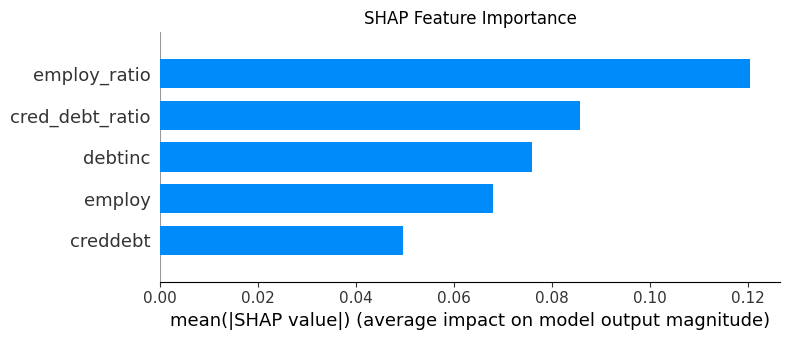

In [28]:
# Install SHAP if not already installed
!pip install shap -q

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer (using the model we just trained)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# 1. Summary Plot (shows global importance + direction)
plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="dot", show=False) # Corrected
plt.title("SHAP Summary Plot (Default = 1)")
plt.tight_layout()
plt.show()

# 2. Feature Importance Bar Plot
plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", show=False) # Corrected
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

# 3. Single prediction example (force plot) - first test sample
shap.initjs()   # ← This line is REQUIRED for the interactive plot

# Interactive colorful force plot (best version for Colab)
shap.force_plot(
    explainer.expected_value[1],
    shap_values[0, :, 1], # Corrected: first sample (0), all features (:), positive class (1)
    X_test.iloc[0],
    feature_names=X_test.columns.tolist()   # shows nice feature names
)